In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from google.colab import files

uploaded = files.upload()  # upload baseline_features_v4_segment_split_train_val_test.npz

Saving baseline_features_v4_segment_split_train_val_test.npz to baseline_features_v4_segment_split_train_val_test.npz


In [ ]:
DATA_NAME = "baseline_features_v4_segment_split_train_val_test.npz"

data = np.load(DATA_NAME, allow_pickle=True)

X_train = data["X_train"]  # (N,125,7)
y_train = data["y_train"]  # strings
X_val   = data["X_val"]
y_val   = data["y_val"]
X_test  = data["X_test"]
y_test  = data["y_test"]
modes   = list(data["modes"])

print("Shapes:")
print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_val  :", X_val.shape,   "y_val  :", y_val.shape)
print("X_test :", X_test.shape,  "y_test :", y_test.shape)
print("Modes  :", modes)

# map string labels -> ints
mode_to_idx = {m:i for i,m in enumerate(modes)}
y_train_i = np.array([mode_to_idx[y] for y in y_train], dtype=np.int64)
y_val_i   = np.array([mode_to_idx[y] for y in y_val],   dtype=np.int64)
y_test_i  = np.array([mode_to_idx[y] for y in y_test],  dtype=np.int64)

# add channel dimension for Conv2D
X_train = X_train[..., np.newaxis].astype(np.float32)  # (N,125,7,1)
X_val   = X_val[..., np.newaxis].astype(np.float32)
X_test  = X_test[..., np.newaxis].astype(np.float32)

print("\nAfter expand dims:")
print("X_train:", X_train.shape)

Shapes:
X_train: (360, 200, 7) y_train: (360,)
X_val  : (1019, 200, 7) y_val  : (1019,)
X_test : (440, 200, 7) y_test : (440,)
Modes  : ['train', 'subway', 'car', 'bus', 'walk']

After expand dims:
X_train: (360, 200, 7, 1)


In [ ]:
def build_widekernel_model(n_classes, input_shape):
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=input_shape),

        # wide temporal kernels (9x1) to increase receptive field
        tf.keras.layers.Conv2D(16, (9,1), activation="relu", padding="same"),
        tf.keras.layers.MaxPool2D((2,1)),

        tf.keras.layers.Conv2D(32, (9,1), activation="relu", padding="same"),
        tf.keras.layers.MaxPool2D((2,1)),

        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(64, activation="relu"),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(n_classes, activation="softmax"),
    ])
    return model

model = build_widekernel_model(len(modes), X_train.shape[1:])
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 200, 7, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 100, 7, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 100, 7, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 50, 7, 32)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 11200)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │       716,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 721,989 (2.75 MB)

 Trainable params: 721,989 (2.75 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 144ms/step - accuracy: 0.6787 - loss: 0.8296 - val_accuracy: 0.7419 - val_loss: 4.5927
Epoch 2/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 159ms/step - accuracy: 0.9835 - loss: 0.0584 - val_accuracy: 0.7419 - val_loss: 8.2752
Epoch 3/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 105ms/step - accuracy: 0.9915 - loss: 0.0137 - val_accuracy: 0.7419 - val_loss: 10.5072
Epoch 4/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 117ms/step - accuracy: 0.9991 - loss: 0.0084 - val_accuracy: 0.7409 - val_loss: 11.5212
Epoch 5/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 110ms/step - accuracy: 1.0000 - loss: 0.0060 - val_accuracy: 0.7380 - val_loss: 13.4394
Epoch 6/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 118ms/step - accuracy: 1.0000 - loss: 0.0022 - val_accuracy: 0.7370 - val_loss: 13.4018


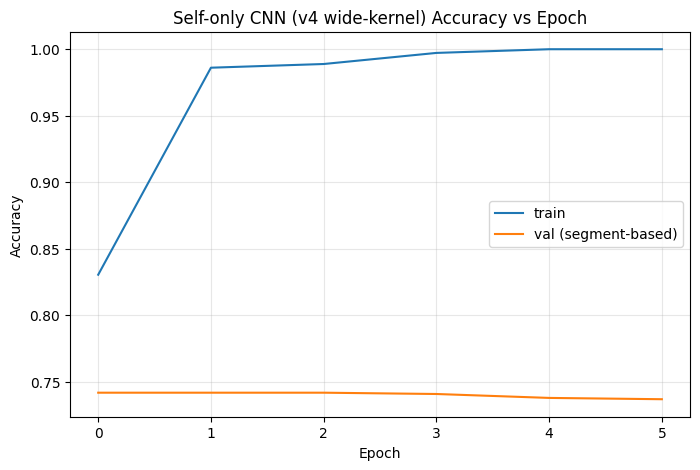

In [ ]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=5,
        restore_best_weights=True
    )
]

hist = model.fit(
    X_train, y_train_i,
    validation_data=(X_val, y_val_i),
    epochs=30,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

plt.figure(figsize=(8,5))
plt.plot(hist.history["accuracy"], label="train")
plt.plot(hist.history["val_accuracy"], label="val (segment-based)")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Self-only CNN (v4 wide-kernel) Accuracy vs Epoch")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

TEST accuracy: 0.9568


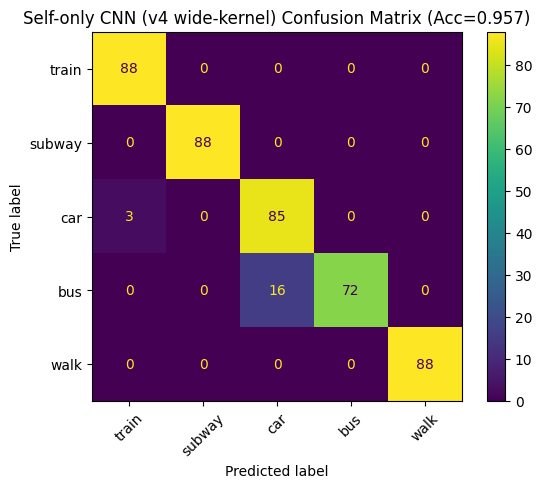


Classification report:
              precision    recall  f1-score   support

       train      0.967     1.000     0.983        88
      subway      1.000     1.000     1.000        88
         car      0.842     0.966     0.899        88
         bus      1.000     0.818     0.900        88
        walk      1.000     1.000     1.000        88

    accuracy                          0.957       440
   macro avg      0.962     0.957     0.957       440
weighted avg      0.962     0.957     0.957       440



In [ ]:
test_loss, test_acc = model.evaluate(X_test, y_test_i, verbose=0)
print(f"TEST accuracy: {test_acc:.4f}")

y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)

cm = confusion_matrix(y_test_i, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=modes)
disp.plot(cmap=None, xticks_rotation=45, values_format="d")
plt.title(f"Self-only CNN (v4 wide-kernel) Confusion Matrix (Acc={test_acc:.3f})")
plt.show()

print("\nClassification report:")
print(classification_report(y_test_i, y_pred, target_names=modes, digits=3))